In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [65]:
featurepd = pd.read_parquet('all_features.parquet')
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
featurepd.head()

,customer_id,customer_type,label,cash_value_ratio,emt_velocity_monthly_mean,income_transaction_gap_score,is_retired,is_unemployed,occupation_sector_id,spending_income_ratio,rapid_outflow_ratio_24h,mean_debit,median_debit,std_debit,iqr_debit,mad_debit,skew_debit,kurt_debit,mean_credit,median_credit,std_credit,iqr_credit,mad_credit,skew_credit,kurt_credit,mean_velocity,median_velocity,std_velocity,iqr_velocity,mad_velocity,skew_velocity,late_night_txn_count,late_night_ratio,weekend_txn_count,activity_span_days,unique_merchant_categories,msb_tx_n,msb_active_days,msb_channels_n,id_msb_in_total,id_msb_out_total,msb_tx_per_day,msb_pass_through_ratio,msb_net_retention_ratio,struct_total_near_n,struct_days_with_near,struct_max_near_in_day,struct_total_near_sum,tx_country_n,tx_province_n,tx_city_n,pct_tx_province_mismatch,pct_tx_city_mismatch
0,SYNID0100000167,IND,NaN,0.000000,0.000000,0.807090,0.0,0.0,2.0,0.000000,0.0,566.226667,256.17,543.750709,472.825,418.568889,1.731656,NaN,3287.950000,4013.39,2000.262562,1899.040,1507.840000,-1.417363,NaN,6.000000,5.0,2.645751,2.5,2.000000,1.457863,2,0.111111,6,90,0.0,18,18,2,9863.85,1698.68,1.000000,0.172213,0.706175,0,0,0,0.0,0,0,0,1.000000,1.000000
1,SYNID0100000431,IND,NaN,0.183417,9.333333,NaN,0.0,0.0,18.0,NaN,0.0,4811.720000,4744.97,1900.494362,1899.615,1288.660000,0.157856,NaN,2641.920000,1553.34,2086.243227,1861.090,1603.586667,1.708762,NaN,36.000000,37.0,1.732051,1.5,1.333333,-1.732051,7,0.064815,34,89,19.0,108,64,5,7925.76,14435.16,1.687500,1.821297,-0.291106,0,0,0,0.0,1,7,21,1.000000,0.750000
2,SYNID0100000485,IND,0.0,0.037841,0.000000,1.460746,1.0,0.0,18.0,0.234281,0.0,1229.440000,1442.61,514.356582,480.085,391.113333,-1.544650,NaN,2434.333333,1922.54,1148.961667,1060.030,877.284444,1.606757,NaN,13.333333,15.0,3.785939,3.5,2.888889,-1.597097,1,0.025000,15,91,12.0,40,28,3,7303.00,3688.32,1.428571,0.505042,0.328867,0,0,0,0.0,1,6,13,0.750000,0.975000
3,SYNID0100000539,IND,NaN,0.000000,3.500000,0.016742,1.0,0.0,18.0,0.863900,0.0,3414.723333,3768.45,717.013859,648.280,550.095556,-1.679701,NaN,54.993333,13.79,80.890791,72.595,62.131111,1.697445,NaN,50.000000,45.0,9.539392,8.5,7.333333,1.710663,7,0.046667,39,91,36.0,150,69,3,164.98,10244.17,2.173913,62.093405,-0.968301,0,0,0,0.0,5,10,40,1.000000,0.673333
4,SYNID0100000932,IND,NaN,0.012255,1.000000,17.062930,1.0,0.0,18.0,1.579105,0.0,9901.203333,6931.56,6542.301581,6015.615,5000.291111,1.621758,NaN,48603.756667,6025.83,75093.889080,65417.370,57804.222222,1.731220,NaN,73.000000,78.0,9.539392,8.5,7.333333,-1.710663,11,0.050228,86,92,35.0,219,83,5,145811.27,29703.61,2.638554,0.203713,0.661526,0,0,0,0.0,2,12,40,0.598174,0.926941


In [66]:
labeled_data = featurepd[featurepd['label'].notna()]
labeled_data.info()

<class 'pandas.DataFrame'>
Index: 1000 entries, 2 to 61340
Data columns (total 53 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   1000 non-null   object 
 1   customer_type                 1000 non-null   object 
 2   label                         1000 non-null   float64
 3   cash_value_ratio              1000 non-null   float64
 4   emt_velocity_monthly_mean     1000 non-null   float64
 5   income_transaction_gap_score  649 non-null    float64
 6   is_retired                    912 non-null    float64
 7   is_unemployed                 912 non-null    float64
 8   occupation_sector_id          912 non-null    float64
 9   spending_income_ratio         649 non-null    float64
 10  rapid_outflow_ratio_24h       1000 non-null   float64
 11  mean_debit                    908 non-null    float64
 12  median_debit                  908 non-null    float64
 13  std_debit         

In [67]:
labeled_data.columns

Index(['customer_id', 'customer_type', 'label', 'cash_value_ratio',
       'emt_velocity_monthly_mean', 'income_transaction_gap_score',
       'is_retired', 'is_unemployed', 'occupation_sector_id',
       'spending_income_ratio', 'rapid_outflow_ratio_24h', 'mean_debit',
       'median_debit', 'std_debit', 'iqr_debit', 'mad_debit', 'skew_debit',
       'kurt_debit', 'mean_credit', 'median_credit', 'std_credit',
       'iqr_credit', 'mad_credit', 'skew_credit', 'kurt_credit',
       'mean_velocity', 'median_velocity', 'std_velocity', 'iqr_velocity',
       'mad_velocity', 'skew_velocity', 'late_night_txn_count',
       'late_night_ratio', 'weekend_txn_count', 'activity_span_days',
       'unique_merchant_categories', 'msb_tx_n', 'msb_active_days',
       'msb_channels_n', 'id_msb_in_total', 'id_msb_out_total',
       'msb_tx_per_day', 'msb_pass_through_ratio', 'msb_net_retention_ratio',
       'struct_total_near_n', 'struct_days_with_near',
       'struct_max_near_in_day', 'struct_total_

In [68]:
from matplotlib import cm

def plot_feature_scatter(col, df=labeled_data, label_col="label"):
    series = df[col]
    if not pd.api.types.is_numeric_dtype(series):
        # Convert non-numeric series to category codes for plotting.
        series = series.astype("category").cat.codes
    labels = df[label_col]
    unique_labels = sorted(labels.dropna().unique())
    if len(unique_labels) == 2:
        colors = ["tab:blue", "tab:orange"]
    else:
        cmap = cm.get_cmap("tab10", len(unique_labels))
        colors = [cmap(i) for i in range(len(unique_labels))]
    plt.figure(figsize=(7, 4))
    for idx, lab in enumerate(unique_labels):
        mask = labels == lab
        plt.scatter(
            df.index[mask],
            series[mask],
            s=12,
            alpha=0.7,
            label=str(lab),
            color=colors[idx],
        )
    plt.title(col)
    plt.xlabel("row")
    plt.ylabel(col)
    plt.legend(title=label_col)
    plt.tight_layout()
    plt.show()

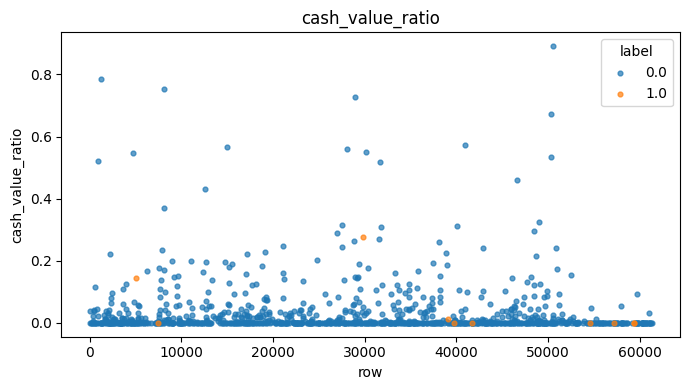

In [69]:
plot_feature_scatter("cash_value_ratio")

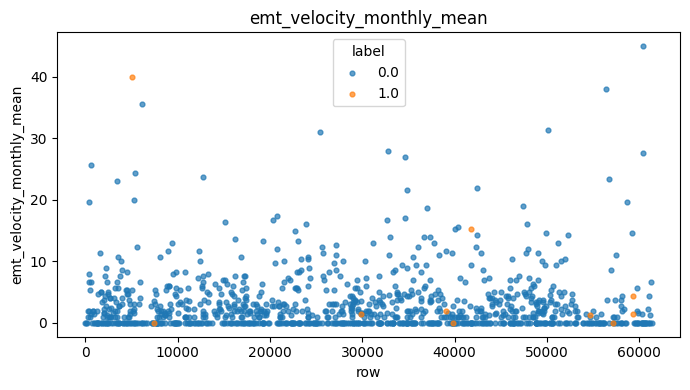

In [70]:
plot_feature_scatter("emt_velocity_monthly_mean")

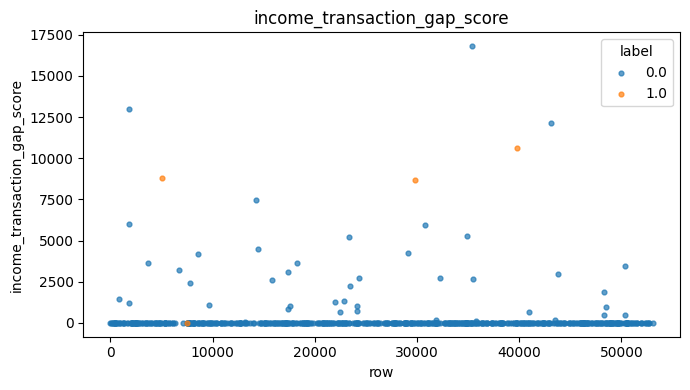

In [71]:
plot_feature_scatter("income_transaction_gap_score")

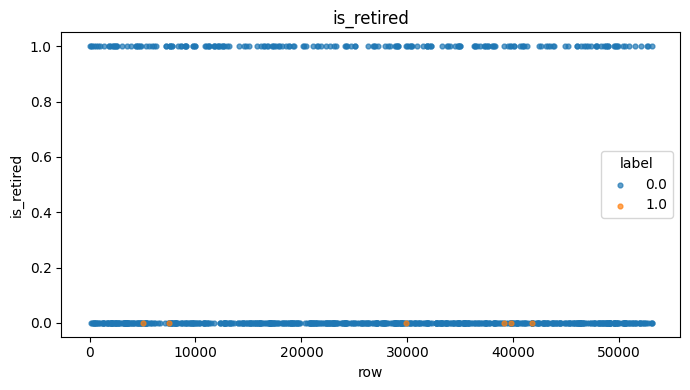

In [72]:
plot_feature_scatter("is_retired")

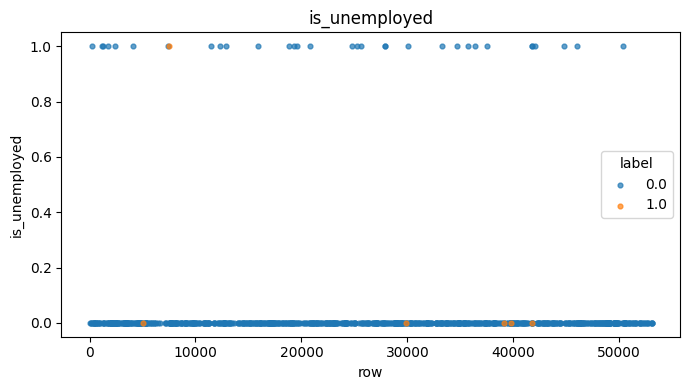

In [73]:
plot_feature_scatter("is_unemployed")

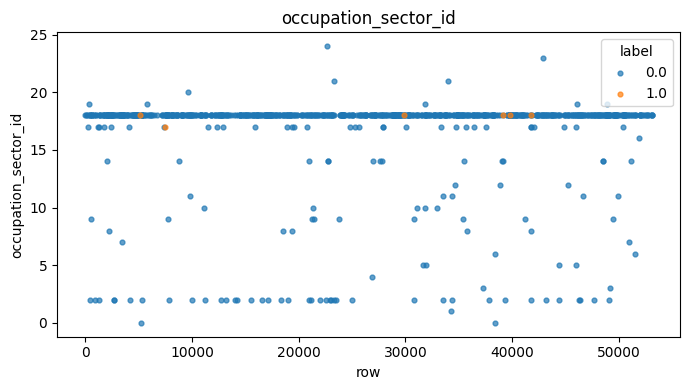

In [74]:
plot_feature_scatter("occupation_sector_id")

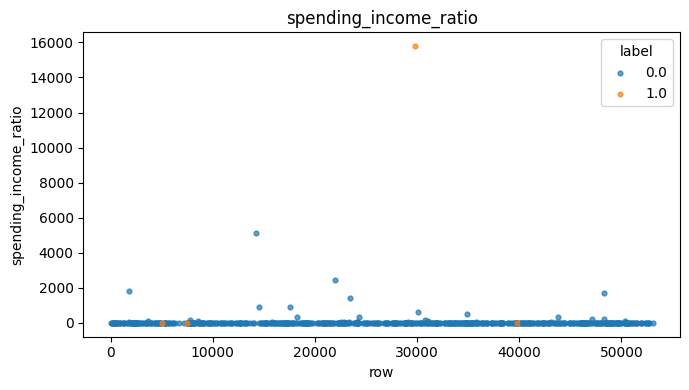

In [75]:
plot_feature_scatter("spending_income_ratio")

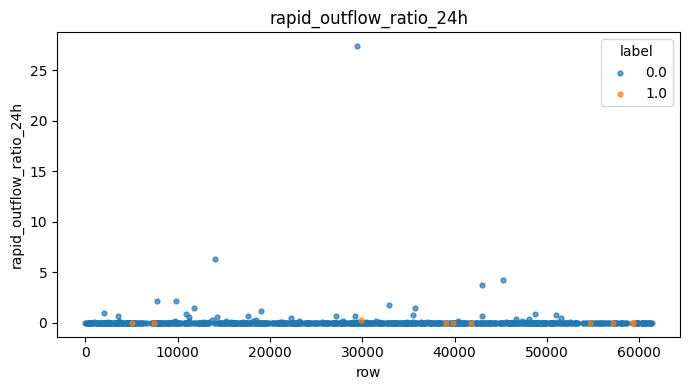

In [76]:
plot_feature_scatter("rapid_outflow_ratio_24h")

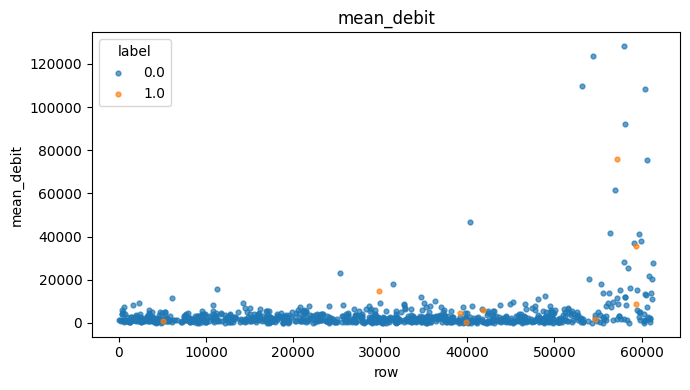

In [77]:
plot_feature_scatter("mean_debit")

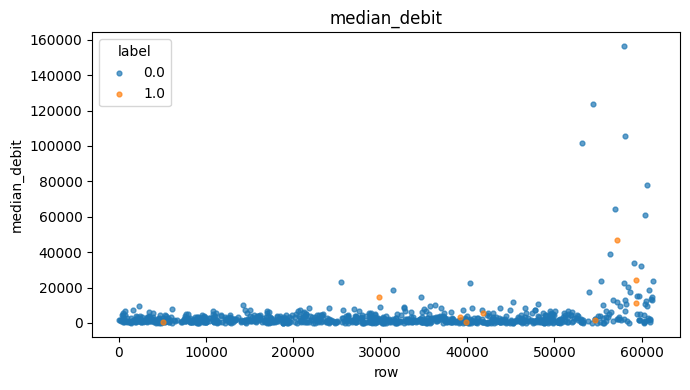

In [78]:
plot_feature_scatter("median_debit")

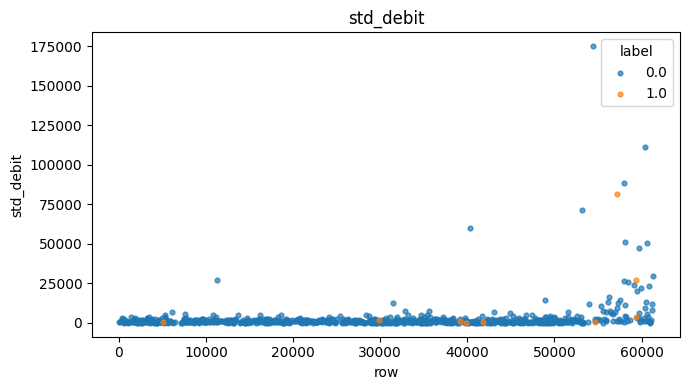

In [79]:
plot_feature_scatter("std_debit")

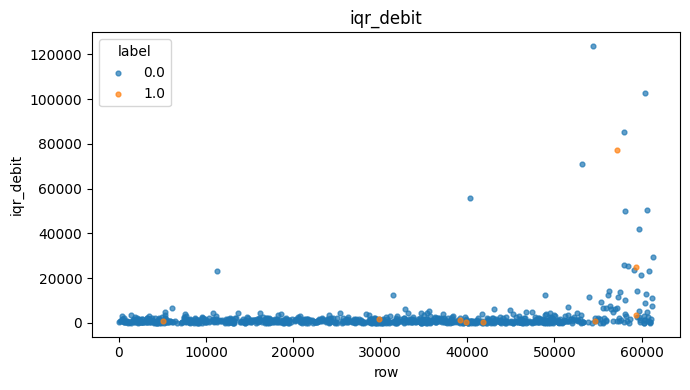

In [80]:
plot_feature_scatter("iqr_debit")

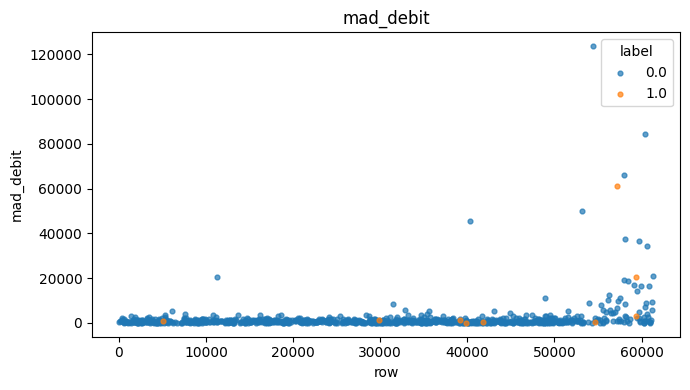

In [81]:
plot_feature_scatter("mad_debit")

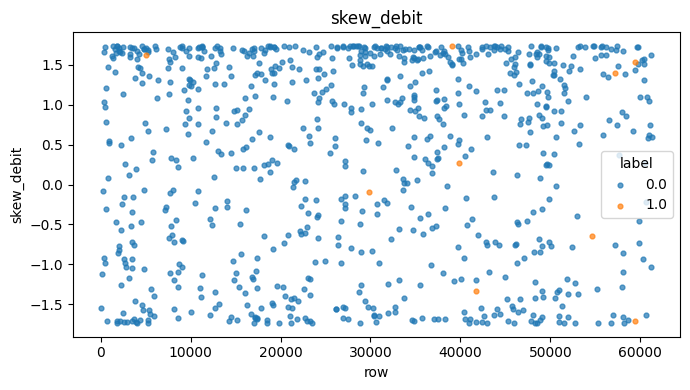

In [82]:
plot_feature_scatter("skew_debit")

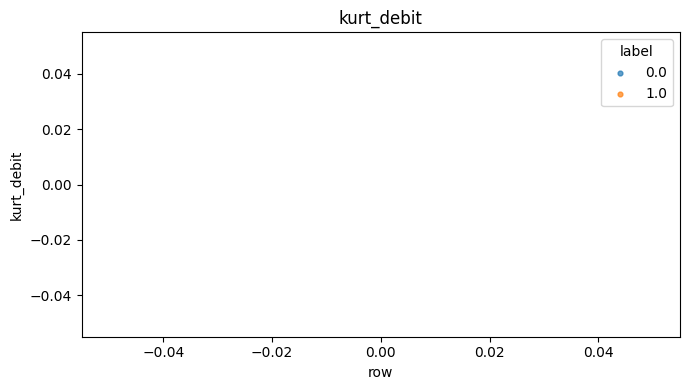

In [83]:
plot_feature_scatter("kurt_debit")

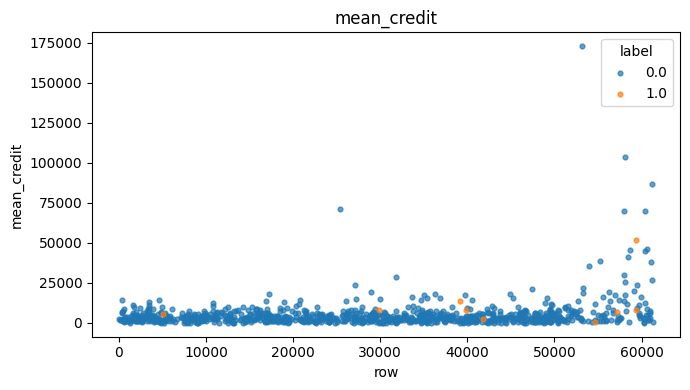

In [84]:
plot_feature_scatter("mean_credit")

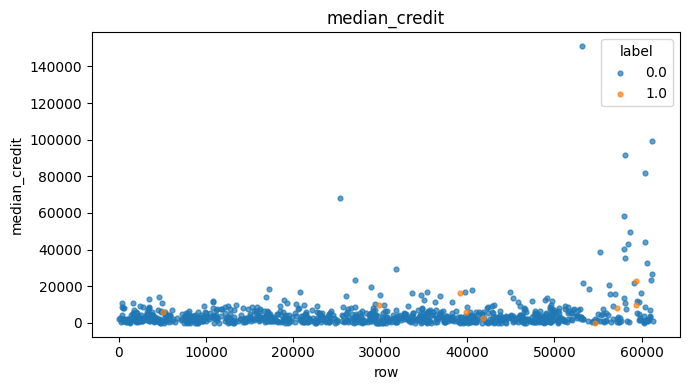

In [85]:
plot_feature_scatter("median_credit")

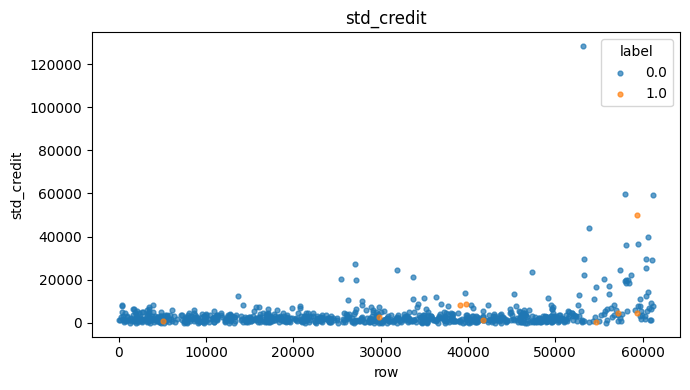

In [86]:
plot_feature_scatter("std_credit")

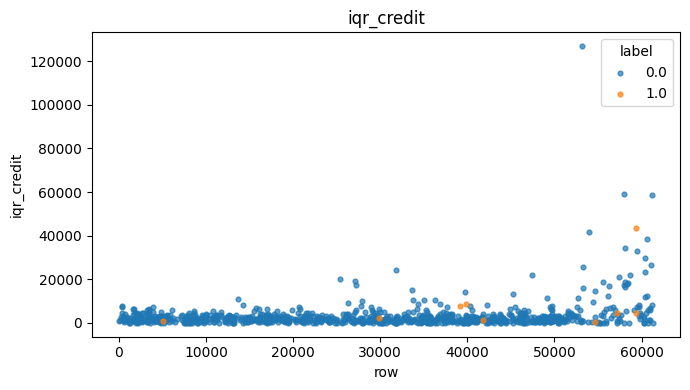

In [87]:
plot_feature_scatter("iqr_credit")

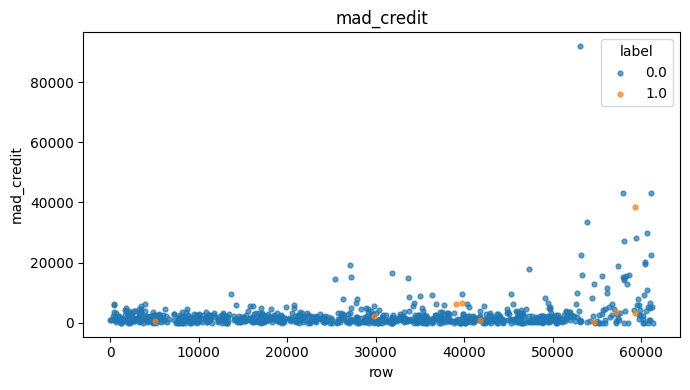

In [88]:
plot_feature_scatter("mad_credit")

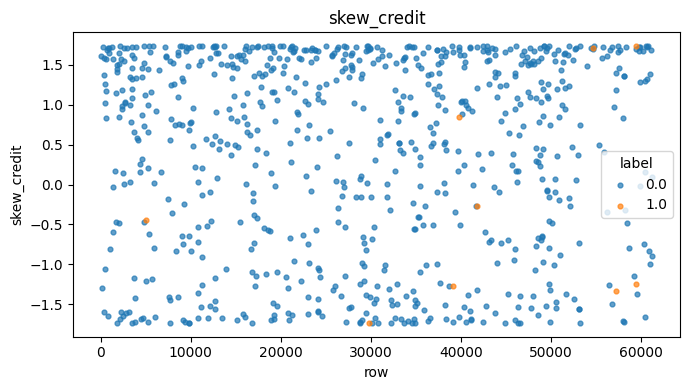

In [89]:
plot_feature_scatter("skew_credit")

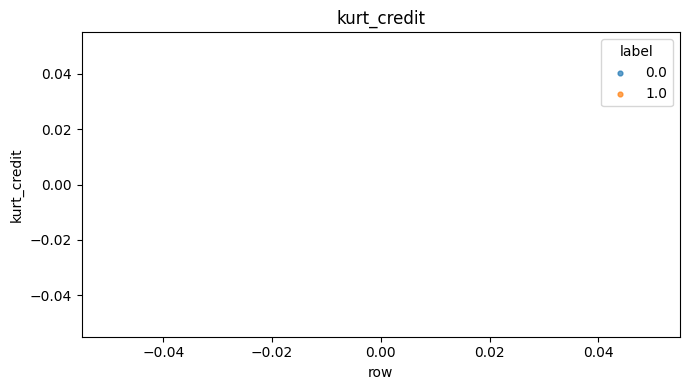

In [90]:
plot_feature_scatter("kurt_credit")

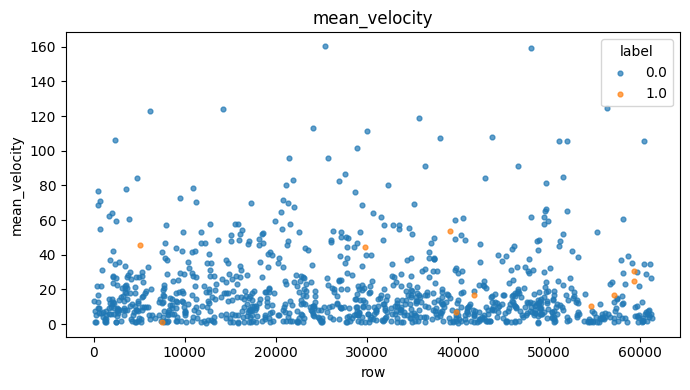

In [91]:
plot_feature_scatter("mean_velocity")

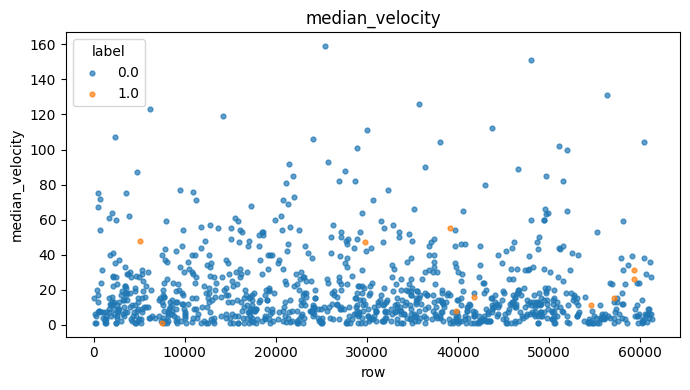

In [92]:
plot_feature_scatter("median_velocity")

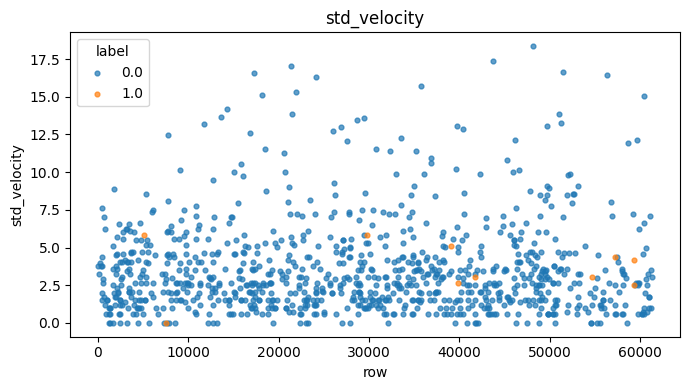

In [93]:
plot_feature_scatter("std_velocity")

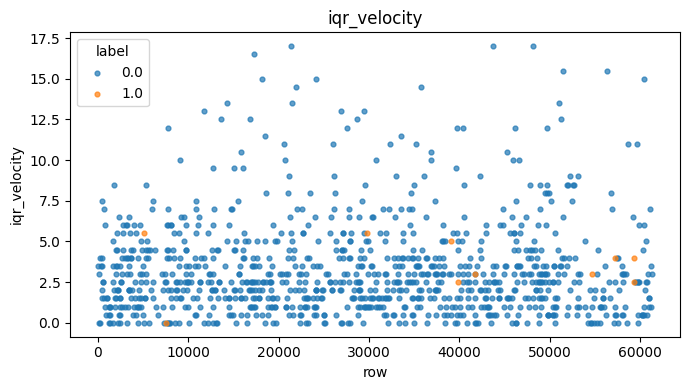

In [94]:
plot_feature_scatter("iqr_velocity")

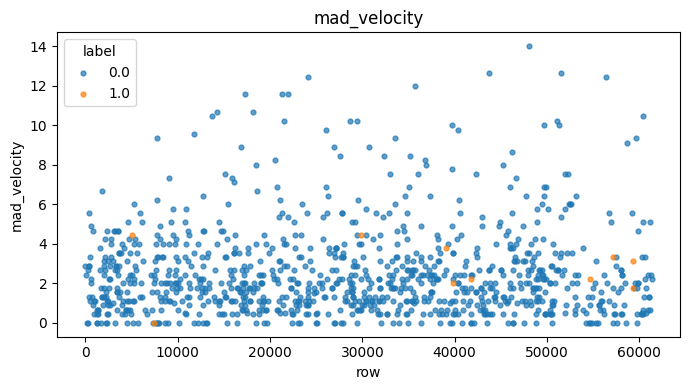

In [95]:
plot_feature_scatter("mad_velocity")

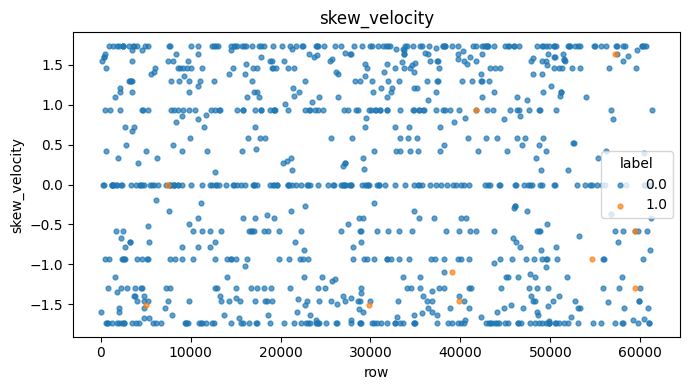

In [96]:
plot_feature_scatter("skew_velocity")

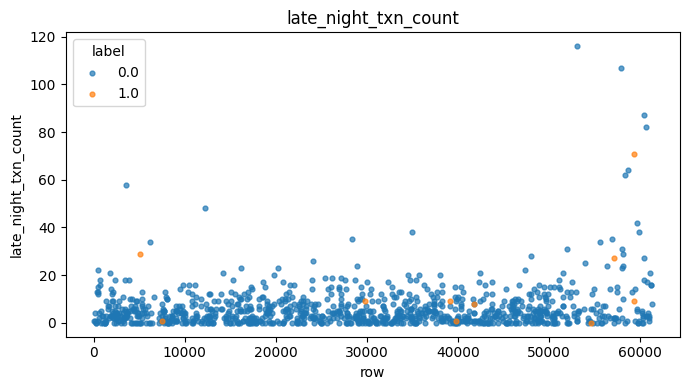

In [97]:
plot_feature_scatter("late_night_txn_count")

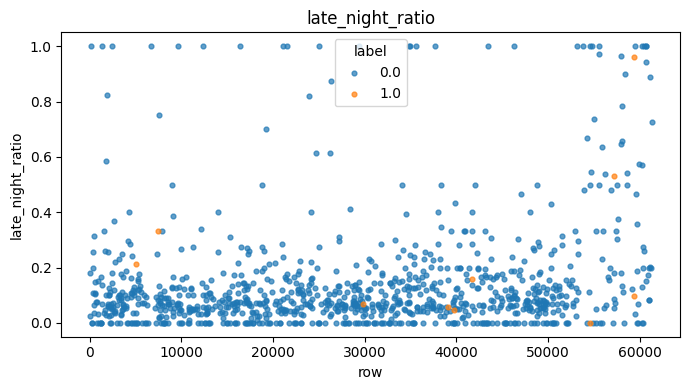

In [98]:
plot_feature_scatter("late_night_ratio")

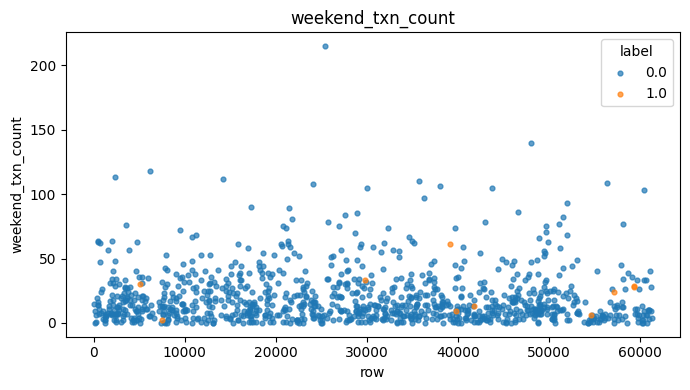

In [99]:
plot_feature_scatter("weekend_txn_count")

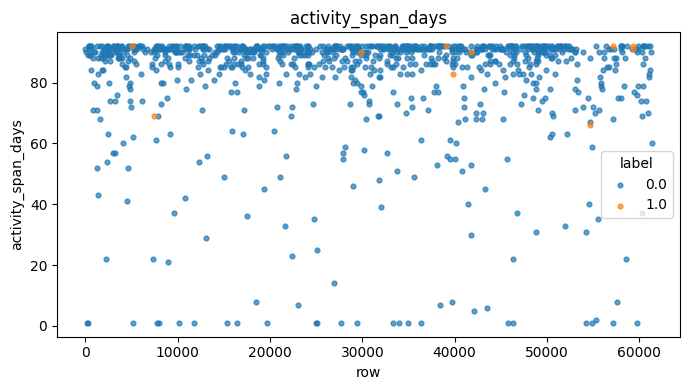

In [100]:
plot_feature_scatter("activity_span_days")

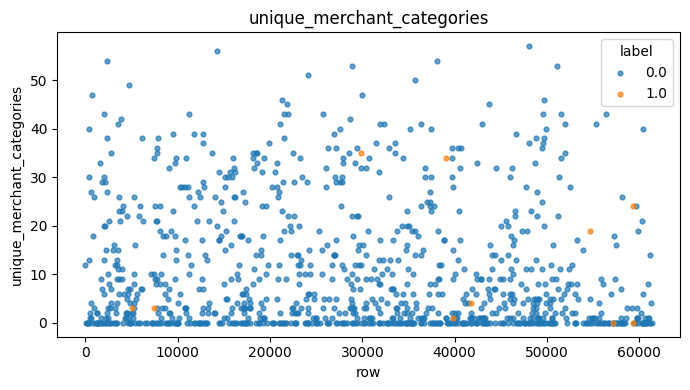

In [101]:
plot_feature_scatter("unique_merchant_categories")

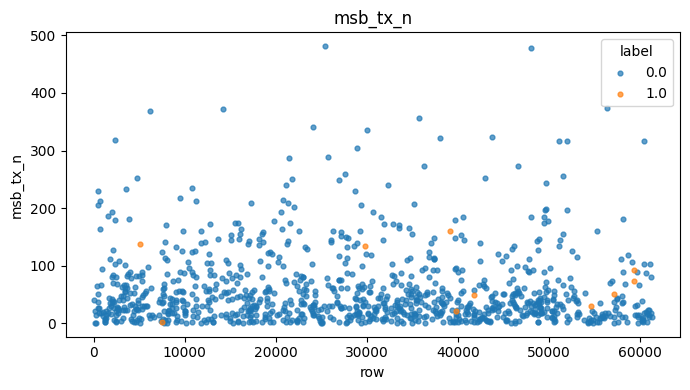

In [102]:
plot_feature_scatter("msb_tx_n")

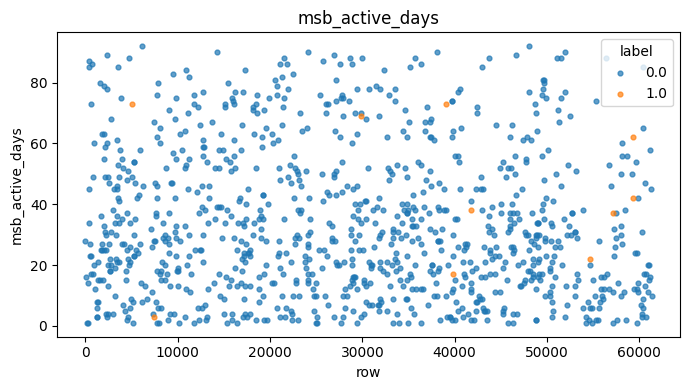

In [103]:
plot_feature_scatter("msb_active_days")

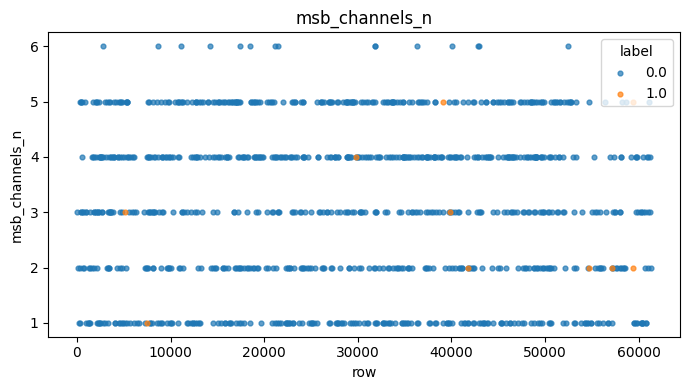

In [104]:
plot_feature_scatter("msb_channels_n")

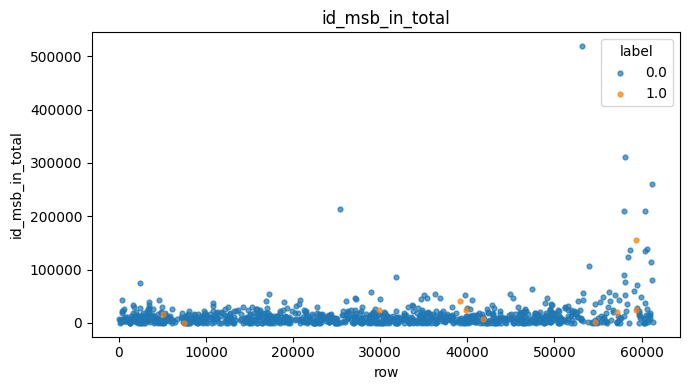

In [105]:
plot_feature_scatter("id_msb_in_total")

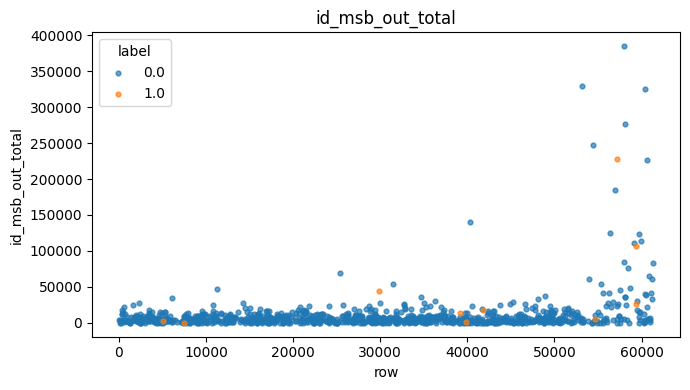

In [106]:
plot_feature_scatter("id_msb_out_total")

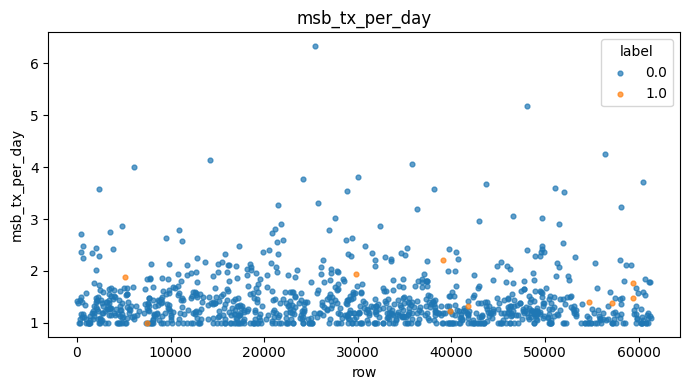

In [107]:
plot_feature_scatter("msb_tx_per_day")

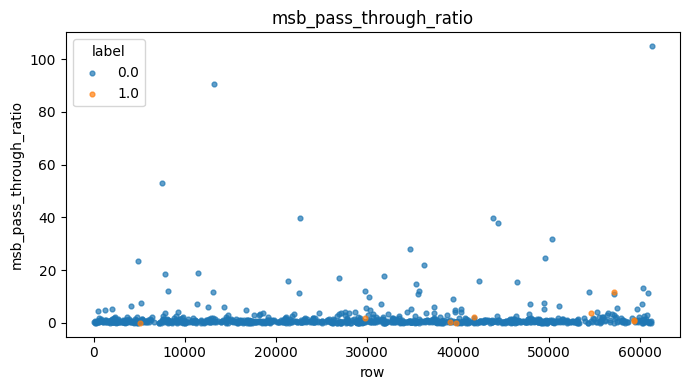

In [108]:
plot_feature_scatter("msb_pass_through_ratio")

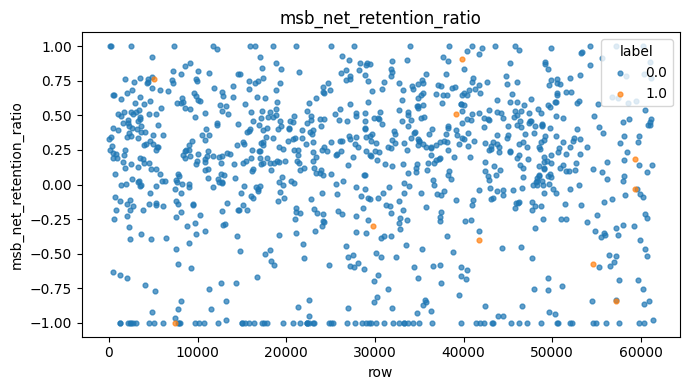

In [109]:
plot_feature_scatter("msb_net_retention_ratio")

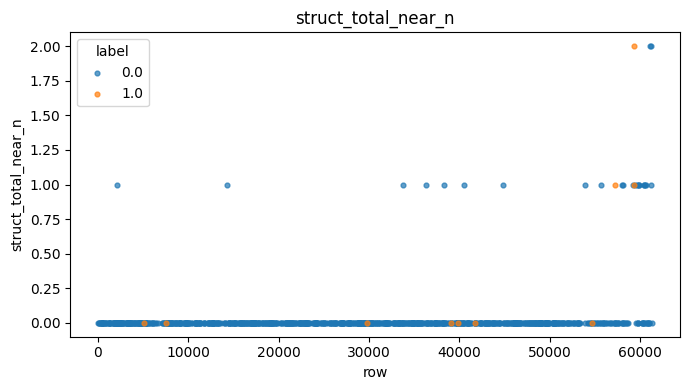

In [110]:
plot_feature_scatter("struct_total_near_n")

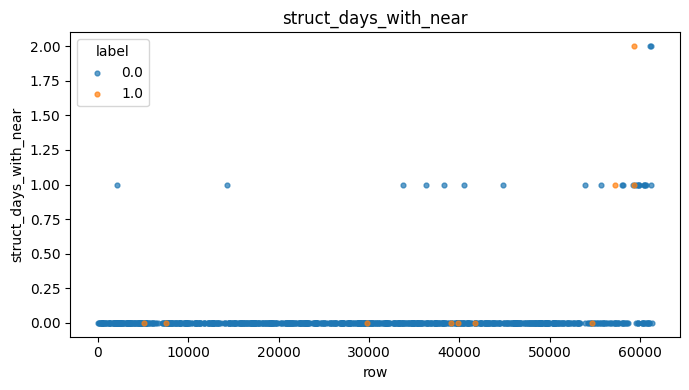

In [111]:
plot_feature_scatter("struct_days_with_near")

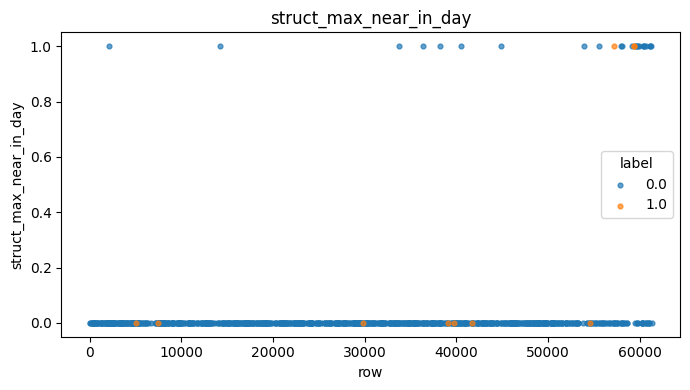

In [112]:
plot_feature_scatter("struct_max_near_in_day")

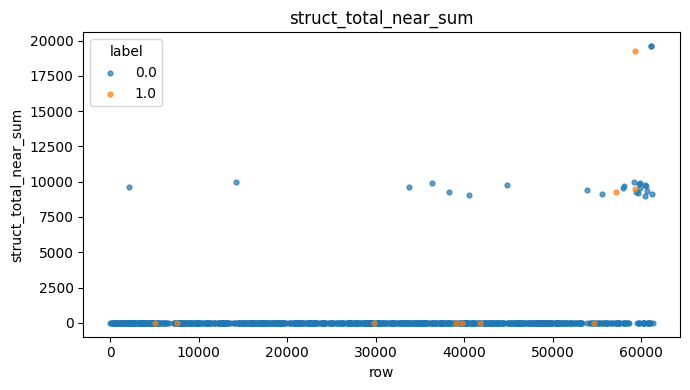

In [113]:
plot_feature_scatter("struct_total_near_sum")

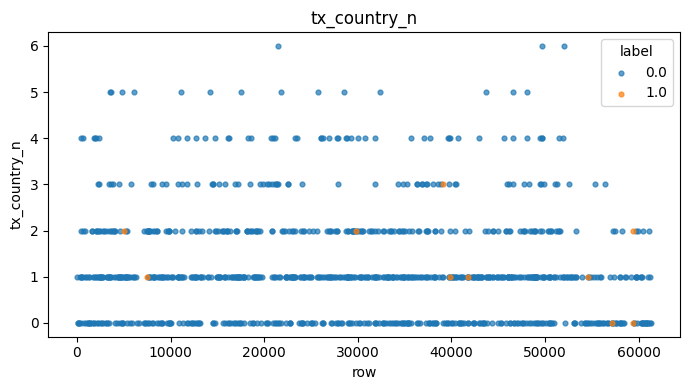

In [114]:
plot_feature_scatter("tx_country_n")

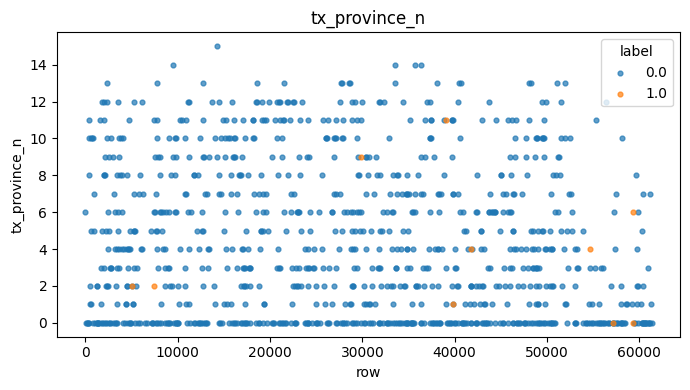

In [115]:
plot_feature_scatter("tx_province_n")

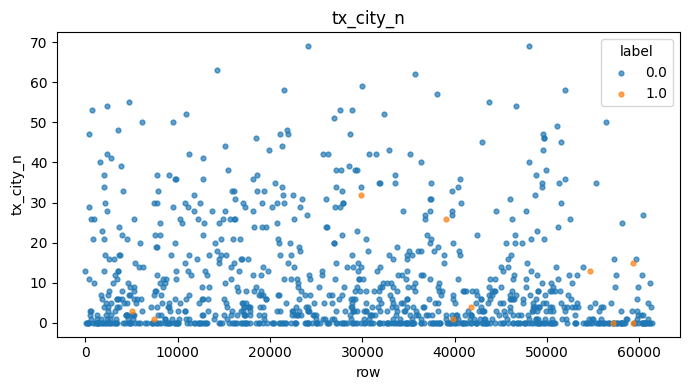

In [116]:
plot_feature_scatter("tx_city_n")

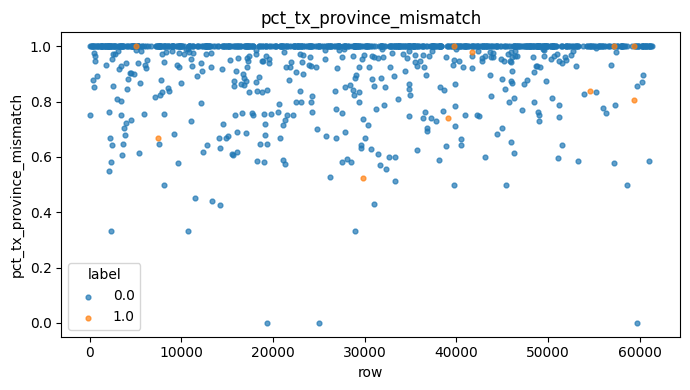

In [117]:
plot_feature_scatter("pct_tx_province_mismatch")

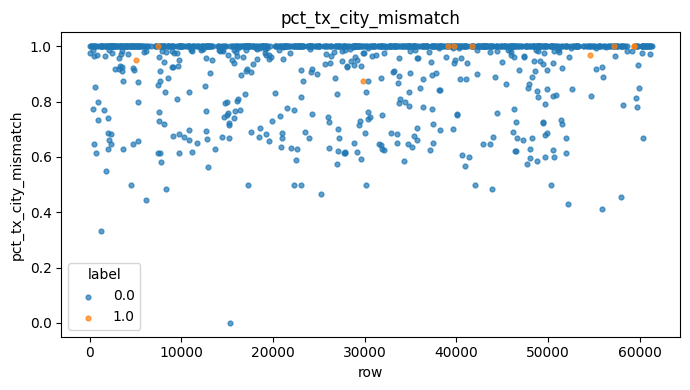

In [118]:
plot_feature_scatter("pct_tx_city_mismatch")